In [1]:
# R2_Straylight_from_Vega.ipynb
# Estimating the stray-light from Vega.
# This notebook is based on the R1_Rosalia_stray_example.ipynb notebook, but it is adapted to the specific case of Vega.
# - Alejandro S. Borlaff / NASA Ames / a.s.borlaff@nasa.gov. March 19, 2026.
import rosalia as rs
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

import os
plt.style.use(os.path.dirname(rs.__file__) + "/style/nature_style.mplstyle")

In [2]:
# Let's find Vega 
import astropy.units as u
from astroquery.simbad import Simbad
from astropy.coordinates import SkyCoord

vega = Simbad.query_object('Vega')
ra_star = vega["ra"][0]
dec_star = vega["dec"][0]

target = SkyCoord(ra_star*u.deg, dec_star*u.deg, frame="icrs")
print(target)


<SkyCoord (ICRS): (ra, dec) in deg
    (279.23473479, 38.78368896)>


In [3]:
# My Vega has an irradiance of 3.06e-15 W/mm^2-um at Roman. In the F129 band, that's 9.9e-16 W/mm^2
ABmag_Vega = 0.905
F_vega = 10**(-0.4*(ABmag_Vega+56.1)) * u.W / u.m**2 / u.Hz 
print(F_vega.to("W/mm2/um", equivalencies=u.spectral_density(12900 * u.AA)))

pixel_size = rs.telescopes.Roman.get_physical_pixelsize("WFI").to("mm")
 
# ----- # 
from astropy import constants as const
f = 2.5E-18 * u.W/u.mm**2 

print(((f * pixel_size.to("mm")**2)/const.h/const.c*12900 * u.AA).decompose())


2.8421126152975483e-15 W / (um mm2)
0.0016235025930325243 1 / s


In [4]:
# These are the coordinates of specially sensitive locations 
# for stray-light, measured in offset degrees from the center of WFI focal plane
dX = np.array([-6.047])# np.array([6.03])
dY = np.array([1.326])# np.array([1.33])
number_of_points_of_interest = len(dX)
# To measure the stray-light from those sources, we need to place the center 
# of Roman / WFI at a certain distance and position angle from the source 
# that generates the stray-light. We will name that source the "offending" source. 

# ROSALIA has a specific tool to compute those locations. 

# The optimal position angle of Roman depends with time. 
# Let's set an approximate time for the Commissioning Activities
from astropy.time import Time
date = Time('2027-06-21T00:00:00.0', format='isot', scale='utc')

ra_wfi = np.zeros(number_of_points_of_interest)
dec_wfi = np.zeros(number_of_points_of_interest)
pa_wfi = np.zeros(number_of_points_of_interest)

for i in range(number_of_points_of_interest):
    offset_pointing = rs.telescopes.Roman.find_wfi_center_for_offset_target(ra_target=target.ra.degree,
                                                      dec_target=target.dec.degree,
                                                      mjd=date.mjd,
                                                      dX=dX[i], dY=dY[i])
    ra_wfi[i] = offset_pointing["ra_wficen"]
    dec_wfi[i] = offset_pointing["dec_wficen"]
    pa_wfi[i] = offset_pointing["pa_wfi"]


ROSALIA Stray-light Mapper: Scanning ... 
 ████████                                     ████████ 
 ████████ ████████                   ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
          ████████ ████████ ████████ ████████          
                   ████████ ████████                   



18it [00:50,  2.79s/it]


SCA 18 - Subarray X=17.92 - Subarray Y=17.92
SCA 18 out of 18: 98.44% completed


18it [00:00, 409.45it/s]
18it [00:00, 414.77it/s]


Output saved in: /Users/aborlaff/NASA/ROSALIA/notebooks/WFI_F129_RA_271.291_DEC_039.328_MJD_61577.00000_PA_014.92_stray.fits
















100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [01:04<00:00,  3.58s/it]


KeyError: Header keyword not found
KeyError: Header keyword not found
KeyError: Header keyword not found
KeyError: Header keyword not found
/Users/aborlaff/NASA/ROSALIA/notebooks/WFI_F129_RA_271.291_DEC_039.328_MJD_61577.00000_PA_014.92_stray_drz.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/WFI_F129_RA_271.291_DEC_039.328_MJD_61577.00000_PA_014.92_stray_drz_scaled.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/WFI_F129_RA_271.291_DEC_039.328_MJD_61577.00000_PA_014.92_stray_drz_scaled.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/WFI_F129_RA_271.291_DEC_039.328_MJD_61577.00000_PA_014.92_stray_drz_scaled.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/WFI_F129_RA_271.291_DEC_039.328_MJD_61577.00000_PA_014.92_stray_main_off.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/WFI_F129_RA_271.291_DEC_039.328_MJD_61577.00000_PA_014.92_stray_main_off_scaled.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/WFI_F129_RA_271.291_DEC_039.328_MJD_61577.00000_PA_014.92_stray_main_off_scaled.fits
/Users/aborlaff/NASA/ROSAL

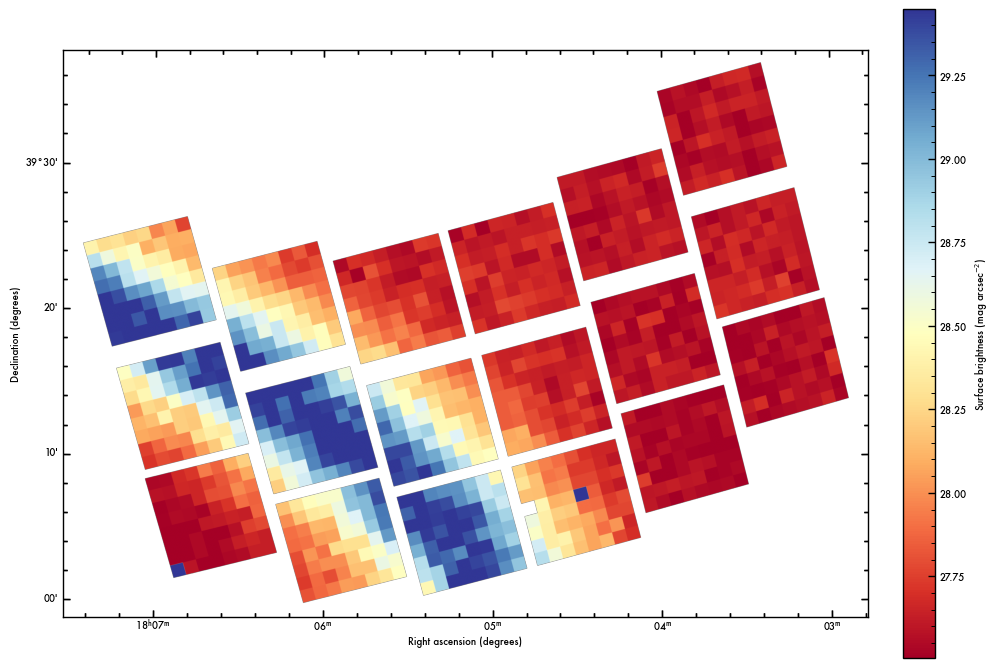

0.0007833313941955568
0.00469099909067154


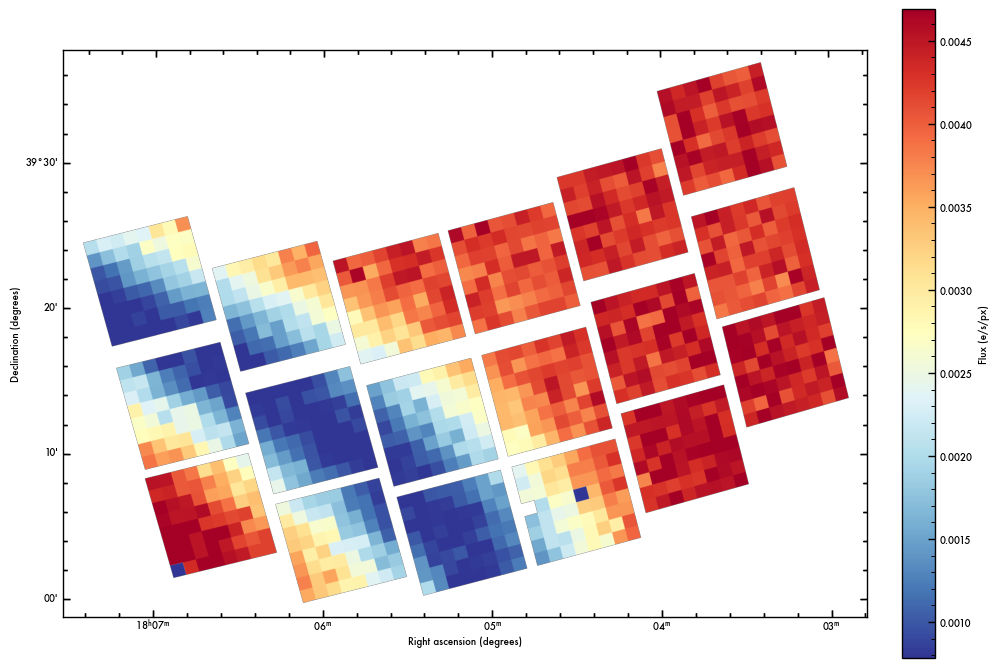

56.0
56.0


IndexError: index 0 is out of bounds for axis 0 with size 0

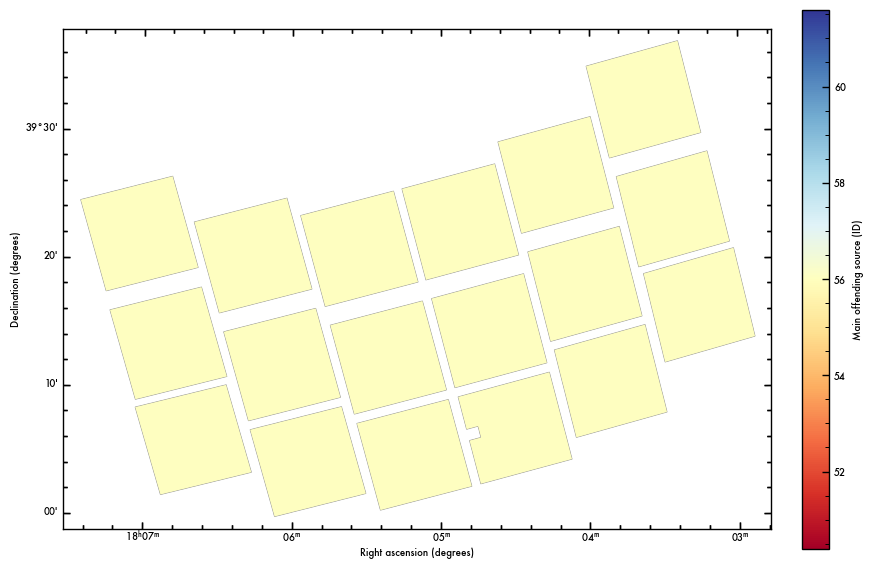

In [5]:
# Now just with Vega
import pandas as pd
catalog = pd.read_csv("WFI_F129_RA_056.658_DEC_024.178_MJD_61192.00000_PA_000.00_source_catalog.csv")

vega_catalog = pd.DataFrame({"ra": catalog["ra"].iloc[56], 
                             "dec": catalog["dec"].iloc[56], 
                             "source_id": catalog["source_id"].iloc[56], 
                             "cat_id": catalog["cat_id"].iloc[56],
                             "mag_lambda": catalog["mag_lambda"].iloc[56]}, index=[0])


for i in range(number_of_points_of_interest):
    ra = ra_wfi[i]
    dec = dec_wfi[i]
    pa = pa_wfi[i]
    mjd = date.mjd
    bandpass="F129"
    exptime=600
    rosalia_stray = rs.correct.rosalia_stray(ra=ra, dec=dec, 
                                             PA=pa, date=date, bandpass=bandpass, 
                                             exptime=exptime, radius=1,
                                             g_mag_max=15, catalog=vega_catalog)

    

In [ ]:
len(vega_catalog["ra"])

In [ ]:
type(np.array(catalog["ra"]))

In [ ]:
vega_catalog is None

In [ ]:
for i in range(number_of_points_of_interest):
    ra = ra_wfi[i]
    dec = dec_wfi[i]
    pa = pa_wfi[i]
    mjd = date.mjd
    bandpass="F129"
    exptime=600
    rosalia_stray = rs.correct.rosalia_stray(ra=ra, dec=dec, 
                                             PA=pa, date=date, bandpass=bandpass, 
                                             exptime=exptime, radius=1,
                                             g_mag_max=15)

In [ ]:
fits_input_name = "WFI_F129_RA_287.134_DEC_038.502_MJD_61365.00000_PA_-07.38.fits"
catalog_name = "WFI_F129_RA_287.134_DEC_038.502_MJD_61365.00000_PA_-07.38_source_catalog.csv"
scaled_main_off = "/Users/aborlaff/NASA/ROSALIA/notebooks/WFI_F129_RA_287.134_DEC_038.502_MJD_61365.00000_PA_-07.38_stray_main_off_scaled.fits"
import rosalia as rs
stars_around_png = rs.plots.make_stars_around_plot(fits_input_name, catalog_name, radius = 0.5, output_name=None)
main_offender_png = rs.plots.make_stray_plot(input_name=scaled_main_off, ext=0, 
                                             mode="main_offender", catalog_name=catalog_name, 
                                             color_label = "Main offending source (ID)")

In [ ]:

def make_stray_plot(input_name, ext, mode="normal", catalog_name=None, 
                    vmin=None, vmax=None, 
                    color_label = 'Surface brightness (mag arcsec$^{-2}$)',
                    cmap="RdYlBu", output_name=None):
    import matplotlib.pyplot as plt
    from astropy.utils.data import get_pkg_data_filename
    from astropy.wcs import WCS as astropy_wcs
    from astropy.io import fits

    import os
    import numpy as np
    import rosalia as rs
    if output_name is None:
        output_name = input_name.replace(".fits", "_" + mode + ".png")
    plt.style.use(os.path.dirname(rs.__file__) + "/style/nature_style.mplstyle")

    hdu = fits.open(input_name)
    data = hdu[ext].data
    wcs = astropy_wcs(hdu[ext].header)

    
    #if mode == "main_offender":
    #    data, header = rs.utils.reproject_roman_wfi_fits(input_name, input_ext=ext,
    #                                            reference_name=flt_name, 
    #                                            reference_ext=np.linspace(1,18,18, dtype="int"))
    
    fig, ax = plt.subplots(figsize=(10, 7), subplot_kw=dict(projection=wcs))

    if mode == "fe2mu":
        data = rs.detectors.fe2mu(data, telescope="Roman", instrument="WFI", filter_name="F129")


    data[np.isinf(data)] = np.nan
    data[data == 0] = np.nan

    vmin = np.nanpercentile(data, 5)
    vmax = np.nanpercentile(data, 95)

    print(vmin)
    print(vmax)
    im=ax.imshow(data, vmin=vmin, vmax=vmax, origin='lower', cmap=cmap)
    ax.set(xlabel='Right ascension (degrees)', ylabel='Declination (degrees)')
    cbar = plt.colorbar(im, ax=ax, location='right', fraction=0.046, pad=0.04)
    cbar.set_label(label=color_label,weight='bold')

    if mode == "main_offender":
        main_offender_db, multiline_text = rs.plots.main_offender_find_fraction_of_map(input_name, catalog_name)
        # 3. Add the text box
        # x, y coordinates are in data units by default
        ax.text(1.25, 0.95, multiline_text, 
            fontsize=9,
            color='black',
            transform=ax.transAxes,
            verticalalignment='top', 
            bbox=dict(facecolor='white', alpha=0.5))
    fig.tight_layout()
    plt.savefig(output_name, dpi=300)
    plt.show()
    return(output_name)
    

def plot_ndi_main_offenders(input_name, scaled_main_off, catalog_name, ndi_level):
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from astropy.io import fits
    import astropy.wcs as astropy_wcs
    import matplotlib.colors as matplotlib_colors

    main_offender_db, multiline_text = rs.plots.main_offender_find_fraction_of_map(scaled_main_off, catalog_name)
    
    # Plot level NDI 
    ndi_name = os.environ["ROSALIACACHE"] + "CORE/NDI/RST/ndi_lvl" + str(ndi_level) + "_mean.fits"
    input_fits = fits.open(input_name)
    pa_point = input_fits[1].header["PA"]
    ra_point = input_fits[1].header["RA_TARG"]
    dec_point = input_fits[1].header["DEC_TARG"]

    if ndi_level==1:
        ndi_linthresh = 0.05
    if ndi_level==2:
        ndi_linthresh = 0.001
    else:
        ndi_linthresh = 0.01
   
    # Make the modified header based on the exposure properties.
    ndi_fits = fits.open(ndi_name)
    w = astropy_wcs.WCS(header=ndi_fits[0].header, fobj=ndi_fits, naxis=2)
    w.wcs.crota = -pa_point,-pa_point
    w.wcs.crval = ra_point,dec_point
    w.wcs.cdelt = -ndi_fits[0].header["CDELT1"],ndi_fits[0].header["CDELT2"]
    print(w)
    ndi_fits[0].header = w.to_header()
    
    fig, ax = plt.subplots(1, 1, figsize=(11, 6), subplot_kw=dict(projection=w))


    # ndi_header = fits.open(ndi_headerlet)[0].header
    im = ax.imshow(ndi_fits[0].data, origin='lower', cmap="RdYlBu_r",
                           norm=matplotlib_colors.SymLogNorm(linthresh=ndi_linthresh, linscale=1,
                                            base=10))
    cbar = plt.colorbar(im, ax=ax, location='top', fraction=0.046, pad=0.04)
    cbar.set_label(label='Normalized Detector Irradiance (unitless)',size=15)

    ndi_w = astropy_wcs.WCS(header=ndi_fits[0].header, fobj=ndi_fits, naxis=2)
    # star_catalog = star_catalog_list[i]
    
    # CAR locations 
    alpha = 1
    import matplotlib.cm as cm

    for i in range(3):
        # CAR 1 A
        x_stars, y_stars = ndi_w.wcs_world2pix(main_offender_db["ra"].iloc[i], main_offender_db["dec"].iloc[i], 0)
        ax.scatter(x_stars, y_stars, marker="h", edgecolor="black", color=cm.hot(i/3), alpha=alpha, s=150/(i+1), label=main_offender_db["source_name"].iloc[i])

    max_extent_ndi = np.abs(ndi_fits[0].header["CDELT2"]) * ndi_fits[0].data.shape[0]/2# This is the radial extent of the NDI map
    print(max_extent_ndi)
    angle_ticks = np.round(np.linspace(-max_extent_ndi, max_extent_ndi, 5),1)
    print(angle_ticks)
    pixel_ticks = angle_ticks/np.abs(ndi_fits[0].header["CDELT2"])  + ndi_fits[0].data.shape[0]/2
    print(pixel_ticks)
    #ax.set_xticks(pixel_ticks, angle_ticks, size=12)
    #ax.set_yticks(pixel_ticks, angle_ticks, size=12)
    ax.set_xlabel("RA (degrees)", size=15)
    ax.set_ylabel("Dec (degrees)", size=15)

    plt.legend(title="Main offenders", fancybox=True, edgecolor="white", bbox_to_anchor=(1.3, 0.5))
    ax.text(1.1, 0.95, multiline_text, 
            fontsize=9,
            color='black',
            transform=ax.transAxes,
            verticalalignment='top', 
            bbox=dict(facecolor='white', alpha=0.5))

    plt.tight_layout()
    plt.savefig(input_name.replace(".fits","_ndi_mainoff_location.png"), dpi=300)

#main_offender_png = make_stray_plot(input_name=scaled_main_off, ext=0, 
#                                    mode="main_offender", catalog_name=catalog_name, 
#                                    color_label = "Main offending source (ID)")

plot_ndi_main_offenders(input_name=fits_input_name, scaled_main_off=scaled_main_off, catalog_name=catalog_name, ndi_level=2)

In [ ]:
main_offender_db, multiline_text = rs.plots.main_offender_find_fraction_of_map(scaled_main_off, catalog_name)
main_offender_db

In [ ]:
Simbad.query_region(279.234100, 38.782993)